In [1]:
from PIL import Image
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from mma.metrics.mma import get_mma
from mma.metrics.seg import get_seg
from mma.metrics.average_precision import get_ap_50
from mma.metrics.aji import get_aji
from mma.metrics.panoptic_quality import get_pq

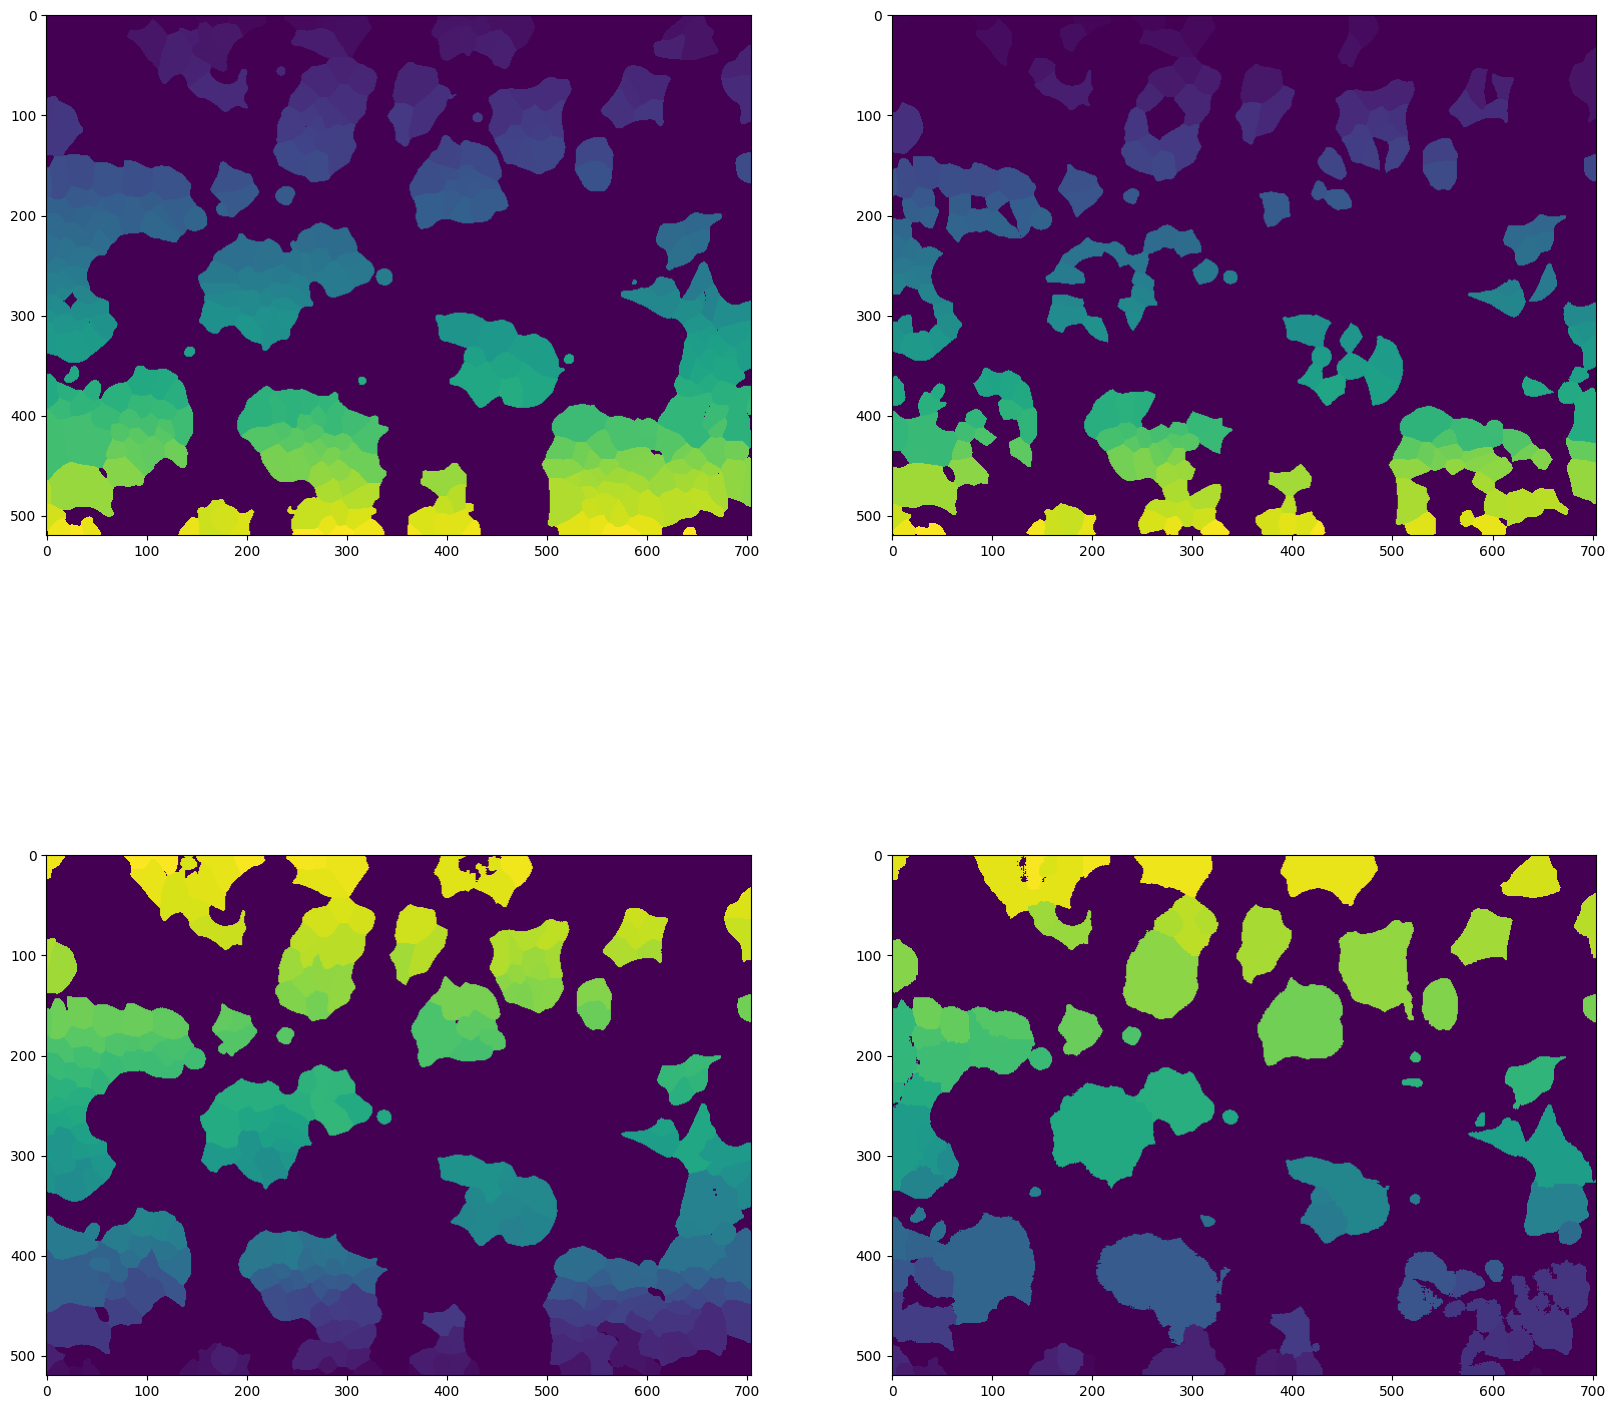

In [19]:
i = 0
base_path = '../mma/livecell model outputs'
dinocell_output = np.load(f'{base_path}/DINOCell/output_{i}.npy')
cellpose_sam_output = np.load(f'{base_path}/Cellpose-SAM/output_{i}.npy')
samcell_livecell_output = np.load(f'{base_path}/SAMCell-LiveCell/output_{i}.npy')
samcell_cyto_output = np.load(f'{base_path}/SAMCell-cyto/output_{i}.npy')

fig, ax = plt.subplots(2, 2, figsize=(20, 20))

ax[0][0].imshow(dinocell_output)
ax[0][1].imshow(cellpose_sam_output)
ax[1][0].imshow(samcell_livecell_output)
ax[1][1].imshow(samcell_cyto_output)
plt.show()

In [20]:
def get_metrics(gts, predicted_gts, model_type=None):
    mmas = []
    mma_greedys = []
    segs = []
    ajis = []
    ap_50s = []
    pqs = []
    for i in tqdm(range(len(gts))):
        gt = gts[i]
        pred = predicted_gts[i]

        mmas.append(round(get_mma(pred, gt), 2))
        mma_greedys.append(round(get_mma(pred, gt, greedy=True), 2))
        segs.append(round(get_seg(pred, gt), 2))
        ajis.append(round(get_aji(pred, gt), 2))
        ap_50s.append(round(get_ap_50(pred, gt), 2))
        pqs.append(round(get_pq(pred, gt), 2))

    save_path = '../mma/livecell model performance'

    np.save(f'{save_path}/{model_type}/mmas.npy', np.array(mmas))
    np.save(f'{save_path}/{model_type}/mma_greedys.npy', np.array(mma_greedys))
    np.save(f'{save_path}/{model_type}/segs.npy', np.array(segs))
    np.save(f'{save_path}/{model_type}/ajis.npy', np.array(ajis))
    np.save(f'{save_path}/{model_type}/ap_50s.npy', np.array(ap_50s))
    np.save(f'{save_path}/{model_type}/pqs.npy', np.array(pqs))

In [ ]:
gts = np.load('../mma/datasets/LiveCell/test/anns.npy')


In [ ]:
model_type = 'SAMCell-LiveCell'
base_path = f'../mma/livecell model outputs/{model_type}'
predicted_gts = []
for i in range(len(gts)):
    model_output = np.load(f'{base_path}/output_{i}.npy')
    predicted_gts.append(model_output)

get_metrics(gts, predicted_gts, model_type)

100%|██████████| 1564/1564 [1:44:13<00:00,  4.00s/it]  
